In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
train = pd.read_csv("../data/train.csv")
stores = pd.read_csv("../data/stores.csv")
features = pd.read_csv("../data/features.csv")

In [6]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [7]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [8]:
#features.head()

In [9]:
data = train.merge(features, on=['Store','Date','IsHoliday'], how='left')
data = data.merge(stores, on=['Store'], how='left')

In [10]:
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [11]:
data['Date'] = pd.to_datetime(data['Date'])

In [12]:
data = pd.get_dummies(data, columns=['Type'], drop_first=True)

In [13]:
data = data.fillna(0)

In [14]:
data.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Size            0
Type_B          0
Type_C          0
dtype: int64

In [15]:
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Week'] = data['Date'].dt.isocalendar().week

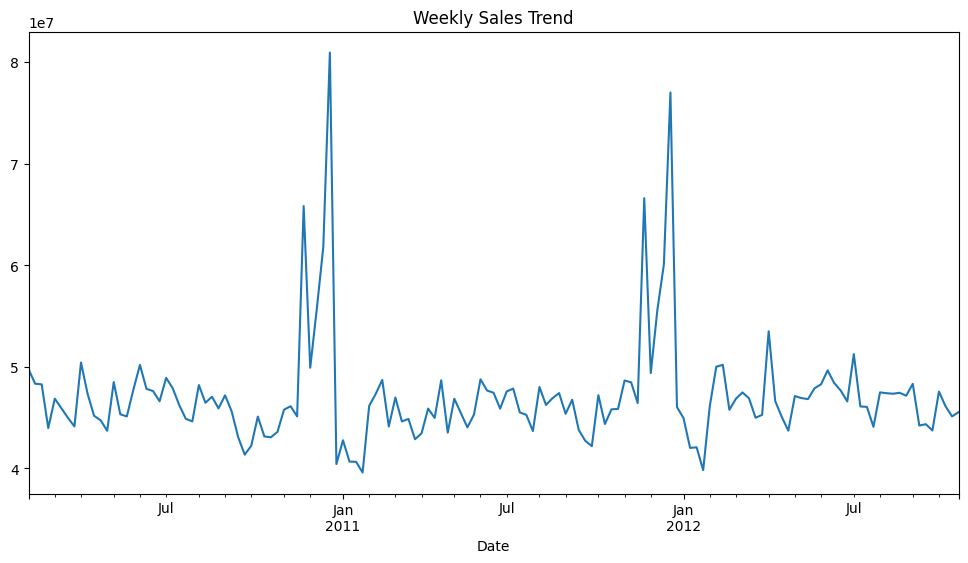

In [16]:
sales_trend = data.groupby('Date')['Weekly_Sales'].sum()
plt.figure(figsize=(12,6))
sales_trend.plot()
plt.title("Weekly Sales Trend")
plt.show()

In [17]:
store_sales = data.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
store_sales.head(10)

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
Name: Weekly_Sales, dtype: float64

In [18]:
dept_sale = data.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False)
dept_sale.head(10)

Dept
92    4.839433e+08
95    4.493202e+08
38    3.931181e+08
72    3.057252e+08
90    2.910685e+08
40    2.889360e+08
2     2.806112e+08
91    2.167817e+08
13    1.973216e+08
8     1.942808e+08
Name: Weekly_Sales, dtype: float64

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

features = data[['Store','Dept','IsHoliday','Temperature','Fuel_Price','CPI','Unemployment','Size','Month','Year','Week','Type_B','Type_C']]
target = data['Weekly_Sales']

x_train,x_test,y_train,y_test = train_test_split(features,target,test_size=0.2,random_state=42)

In [20]:
model = LinearRegression()

model.fit(x_train,y_train)

predictions = model.predict(x_test)

In [21]:
from sklearn.metrics import r2_score,mean_absolute_error

In [22]:
print("r2_score",r2_score(y_test,predictions))
print("mean_absolute_error",mean_absolute_error(y_test,predictions))

r2_score 0.09134793106883554
mean_absolute_error 14570.28888004864


In [23]:
from sklearn.ensemble import RandomForestRegressor

In [24]:
rf_model = RandomForestRegressor(n_estimators=50, random_state=42)

rf_model.fit(x_train, y_train)

rf_predictions = rf_model.predict(x_test)

In [25]:
print("r2_score using RandomForestRegressor",r2_score(y_test,rf_predictions))
print("mean_absolute_error using RandomForestRegressor",mean_absolute_error(y_test,rf_predictions))

r2_score using RandomForestRegressor 0.9741398036948802
mean_absolute_error using RandomForestRegressor 1443.92930055744


In [26]:
data.to_csv("cleaned_sales_data.csv", index=False)